### LIBs

In [79]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import plotly.express as px
from streamlit import header
from sklearn.model_selection import StratifiedKFold,ParameterGrid

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression as LR
from sklearn.model_selection import train_test_split
import category_encoders as ce
from unicodedata import category
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score,roc_auc_score,ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.pipeline import Pipeline
import tensorflow as tf
from tensorflow.keras import Sequential
warnings.filterwarnings('ignore')


### Func

In [80]:
def model_evaluation(y_true, y_pred , std_dev=None):
    print("Accuracy:", accuracy_score(y_true, y_pred))
    if std_dev is not None:
        print("standard deviation:", std_dev)    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    
    rec=recall_score(y_true, y_pred, average="macro")
    f1 = f1_score(y_true, y_pred, average="macro")
    print("Recall:", rec)
    print("F1 :", f1)


In [81]:
def tune_logistic_full_recall_no_pipeline(x_train, y_train, x_test, y_test):
    param_grid = [
        {
            "penalty": ["l2"],
            "solver": ["lbfgs", "liblinear", "saga"],
            "C": [0.003,0.001,0.03,0.01, 0.1,0.3, 1, 3, 5, 10],
            "class_weight": ["balanced"]
        }
    ]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    best_score = -1
    best_params = None
    for params in param_grid:
        for comb in ParameterGrid(params):
            all_racall = []
            for train_idx, val_idx in cv.split(x_train, y_train):
                new_xtrain = x_train.iloc[train_idx]
                new_xval = x_train.iloc[val_idx]

                new_ytrain = y_train.iloc[train_idx]
                new_yval = y_train.iloc[val_idx]

                scaler = StandardScaler()
                scaled_xtrain = scaler.fit_transform(new_xtrain)
                scaled_xval = scaler.transform(new_xval)

                model = LR(random_state=1, **comb)
                model.fit(scaled_xtrain, new_ytrain)

                y_pred = model.predict(scaled_xval)
                all_racall.append(recall_score(new_yval, y_pred))

            mean_recall = np.mean(all_racall)

            if mean_recall > best_score:
                best_score = mean_recall
                best_params = comb

    final_scaler = StandardScaler()
    x_train_scaled = final_scaler.fit_transform(x_train)
    x_test_scaled = final_scaler.transform(x_test)

    best_model = LR(random_state=1, **best_params)
    best_model.fit(x_train_scaled, y_train)

    y_pred = best_model.predict(x_test_scaled)
    

    print("Best Params:", best_params)
    print("Best CV Recall:", best_score)
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    y_prob = best_model.predict_proba(x_test_scaled)[:, 1]
    print("Test ROC-AUC:", roc_auc_score(y_test, y_prob))

    return best_model, final_scaler, best_params, best_score

In [82]:

def find_best_threshold_from_cv(x_train, y_train, best_params):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    oof_prob = np.zeros(len(x_train)) 
    for train_idx, val_idx in cv.split(x_train, y_train):
        
        x_tr_fold = x_train.iloc[train_idx]
        x_val_fold = x_train.iloc[val_idx]
        y_tr_fold = y_train.iloc[train_idx]
        y_val_fold = y_train.iloc[val_idx]

        scaler = StandardScaler()
        x_tr_fold_scaled = scaler.fit_transform(x_tr_fold)
        x_val_fold_scaled = scaler.transform(x_val_fold)

        model = LR(random_state=1, max_iter=2000, **best_params)
        model.fit(x_tr_fold_scaled, y_tr_fold)

        oof_prob[val_idx] = model.predict_proba(x_val_fold_scaled)[:, 1]

    thresholds = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5,0.55, 0.6, 0.65, 0.7, 0.75, 0.8]

    results = []

    y_true = y_train.values if hasattr(y_train, "values") else y_train

    for th in thresholds:
        y_pred = (oof_prob >= th).astype(int)

        tp = ((y_true == 1) & (y_pred == 1)).sum()
        tn = ((y_true == 0) & (y_pred == 0)).sum()
        fp = ((y_true == 0) & (y_pred == 1)).sum()
        fn = ((y_true == 1) & (y_pred == 0)).sum()

        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0

        results.append({
            "threshold": th,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "recall": recall,
            "precision": precision
        })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(["FN", "FP", "threshold"]).reset_index(drop=True)

    print(results_df)
    best_threshold = results_df.loc[0, "threshold"]
    return best_threshold, results_df

### DATA

In [83]:
df = pd.read_csv('Gestational_Diabetic_Dat_Set.csv')


In [84]:
df.head()

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM)
0,1,22,2,1,NaN,55.0,0,0,0,0,102.0,69,NaN,12.0,0,0,0
1,2,26,2,1,NaN,53.0,0,0,0,0,101.0,63,NaN,12.4,0,0,0
2,3,29,1,0,NaN,50.0,0,0,0,0,118.0,79,NaN,14.3,0,0,0
3,4,28,2,1,NaN,51.0,0,0,0,0,99.0,70,NaN,15.0,0,0,0
4,5,21,2,1,NaN,52.0,0,0,0,0,116.0,65,NaN,15.0,0,0,0


### EDA

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3525 entries, 0 to 3524
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Case Number                      3525 non-null   int64  
 1   Age                              3525 non-null   int64  
 2   No of Pregnancy                  3525 non-null   int64  
 3   Gestation in previous Pregnancy  3525 non-null   int64  
 4   BMI                              2444 non-null   float64
 5   HDL                              2524 non-null   float64
 6   Family History                   3525 non-null   int64  
 7   unexplained prenetal loss        3525 non-null   int64  
 8   Large Child or Birth Default     3525 non-null   int64  
 9   PCOS                             3525 non-null   int64  
 10  Sys BP                           1820 non-null   float64
 11  Dia BP                           3525 non-null   int64  
 12  OGTT                

In [86]:
df.describe()

,Case Number,Age,No of Pregnancy,Gestation in previous Pregnancy,BMI,HDL,Family History,unexplained prenetal loss,Large Child or Birth Default,PCOS,Sys BP,Dia BP,OGTT,Hemoglobin,Sedentary Lifestyle,Prediabetes,Class Label(GDM /Non GDM)
count,3525.000000,3525.000000,3525.000000,3525.000000,2444.000000,2524.000000,3525.000000,3525.000000,3525.00000,3525.000000,1820.000000,3525.000000,3012.000000,3525.000000,3525.000000,3525.000000,3525.000000
mean,1763.000000,32.581277,2.076312,0.960851,27.854092,46.471870,0.498156,0.364823,0.35773,0.264681,135.762088,81.538156,170.707503,13.959801,0.449645,0.293050,0.389220
std,1017.724177,6.169107,0.838637,0.722313,5.714737,10.800813,0.500068,0.481449,0.47940,0.441226,22.742844,11.379758,48.160549,1.863969,0.497529,0.455226,0.487643
min,1.000000,20.000000,1.000000,0.000000,13.300000,15.000000,0.000000,0.000000,0.00000,0.000000,90.000000,60.000000,80.000000,8.800000,0.000000,0.000000,0.000000
25%,882.000000,28.000000,1.000000,0.000000,24.400000,42.000000,0.000000,0.000000,0.00000,0.000000,122.000000,74.000000,142.000000,12.700000,0.000000,0.000000,0.000000
50%,1763.000000,32.000000,2.000000,1.000000,27.500000,49.000000,0.000000,0.000000,0.00000,0.000000,132.000000,81.000000,156.000000,14.000000,0.000000,0.000000,0.000000
75%,2644.000000,37.000000,3.000000,1.000000,31.000000,55.000000,1.000000,1.000000,1.00000,1.000000,153.000000,86.000000,195.000000,15.000000,1.000000,1.000000,1.000000
max,3525.000000,45.000000,4.000000,2.000000,45.000000,70.000000,1.000000,1.000000,1.00000,1.000000,185.000000,124.000000,403.000000,18.000000,1.000000,1.000000,1.000000


In [87]:
df.isna().sum()

Case Number                           0
Age                                   0
No of Pregnancy                       0
Gestation in previous Pregnancy       0
BMI                                1081
HDL                                1001
Family History                        0
unexplained prenetal loss             0
Large Child or Birth Default          0
PCOS                                  0
Sys BP                             1705
Dia BP                                0
OGTT                                513
Hemoglobin                            0
Sedentary Lifestyle                   0
Prediabetes                           0
Class Label(GDM /Non GDM)             0
dtype: int64

In [88]:
df = df.rename(columns={
    "No of Pregnancy": "No_of_Pregnancy",
    "Gestation in previous Pregnancy": "Gestation_in_previous_Pregnancy",
    "Family History": "Family_History",
    "unexplained prenetal loss": "unexplained_prenetal_loss",
    "Large Child or Birth Default": "Large_Child_or_Birth_Default",
    "Class Label(GDM /Non GDM)": "GDM", 
    "Dia BP": "dia", 
    "Sys BP": "Sys", 
    "Sedentary Lifestyle": "Sedentary_Lifestyle", 
}, errors="ignore") 

In [89]:
df.isna().sum()

Case Number                           0
Age                                   0
No_of_Pregnancy                       0
Gestation_in_previous_Pregnancy       0
BMI                                1081
HDL                                1001
Family_History                        0
unexplained_prenetal_loss             0
Large_Child_or_Birth_Default          0
PCOS                                  0
Sys                                1705
dia                                   0
OGTT                                513
Hemoglobin                            0
Sedentary_Lifestyle                   0
Prediabetes                           0
GDM                                   0
dtype: int64

In [90]:
df['GDM'].value_counts()

GDM
0    2153
1    1372
Name: count, dtype: int64

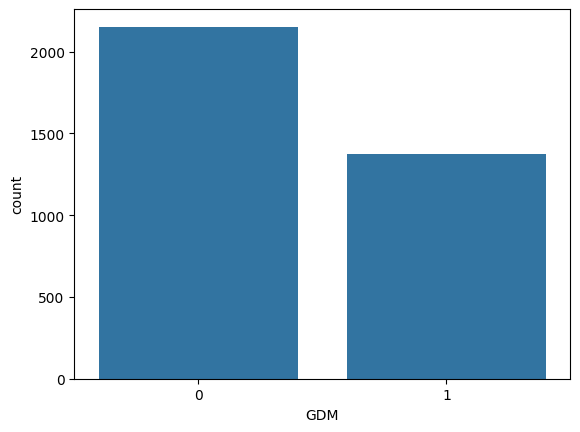

In [91]:
sns.countplot(x='GDM',data = df)
plt.show()

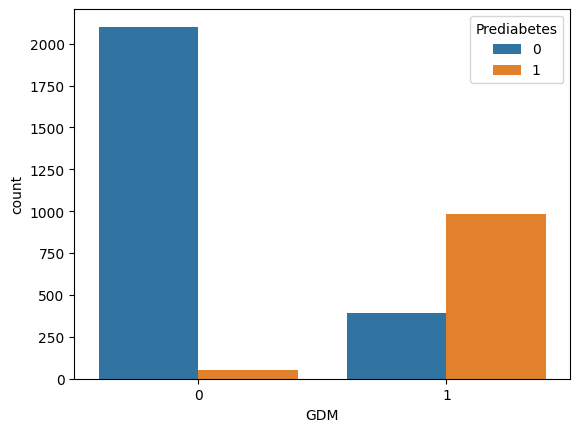

In [92]:
sns.countplot(x='GDM',hue='Prediabetes',data = df)
plt.show()

<Axes: xlabel='Sedentary_Lifestyle', ylabel='BMI'>

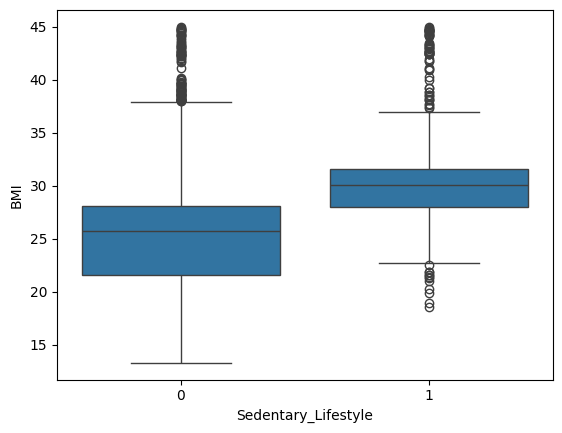

In [93]:
# if prediabetes = 1 at most GDM = 1
sns.boxplot(x='Sedentary_Lifestyle',y='BMI',data = df)

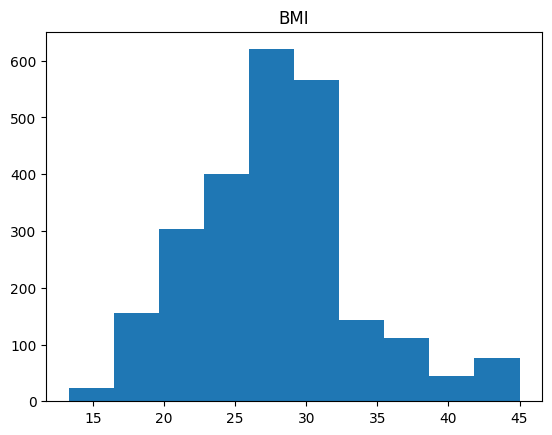

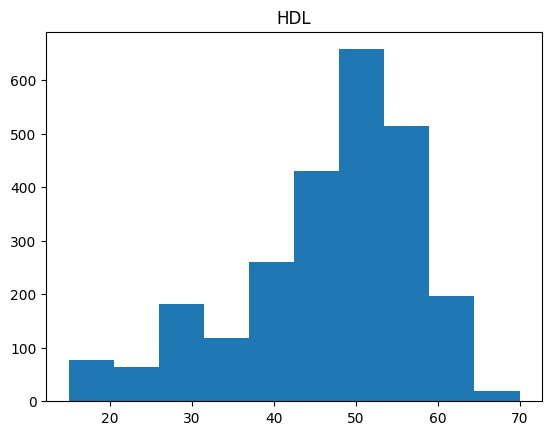

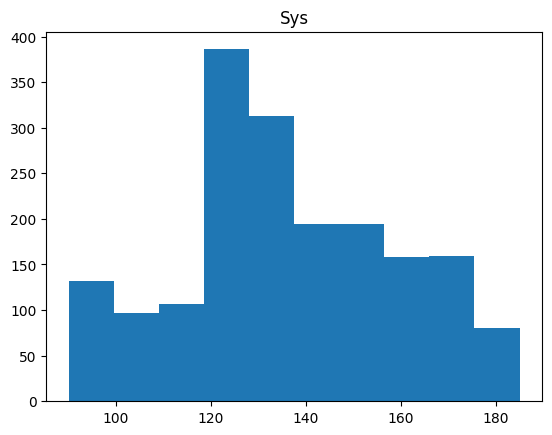

In [94]:
plt.hist(df["BMI"])
plt.title("BMI")
plt.show()

plt.hist(df["HDL"])
plt.title("HDL")
plt.show()

plt.hist(df["Sys"])
plt.title("Sys")
plt.show()

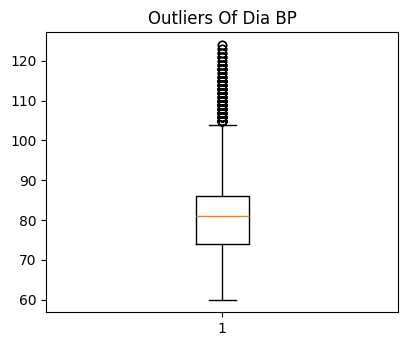

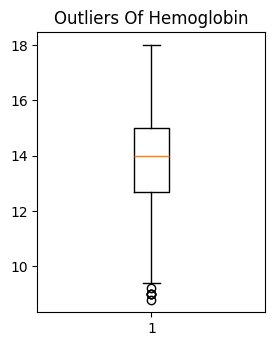

In [95]:

plt.figure(figsize=(10,8))
plt.subplot(2,2,2)
plt.boxplot(df["dia"])
plt.title("Outliers Of Dia BP")
plt.show()

plt.figure(figsize=(10,8))
plt.subplot(2,3,1)
plt.boxplot(df["Hemoglobin"])
plt.title("Outliers Of Hemoglobin")
plt.show()




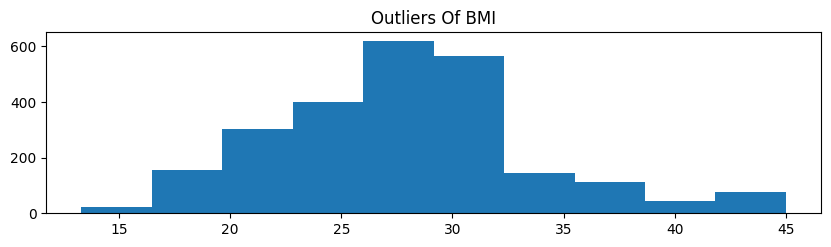

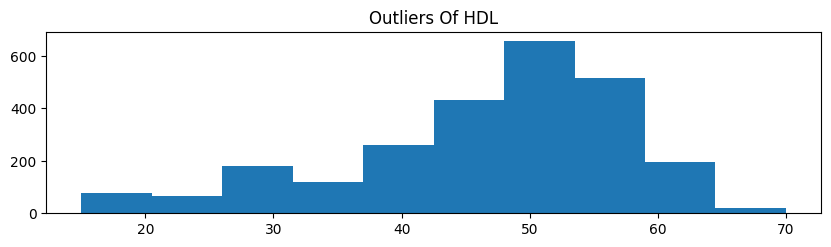

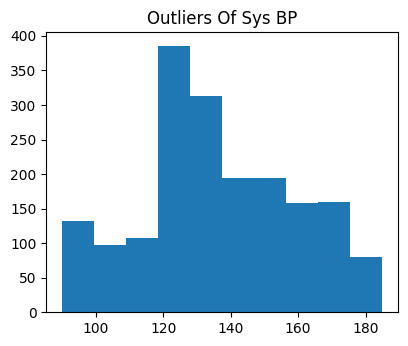

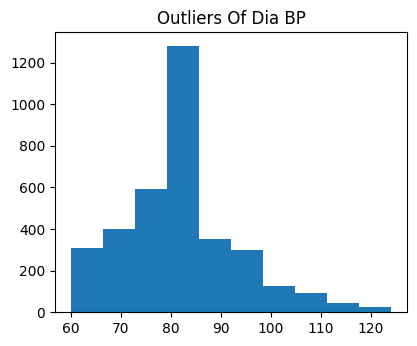

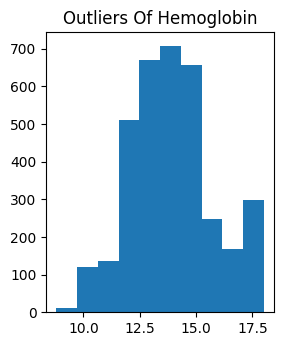

Text(0.5, 1.0, 'Outliers OGTT')

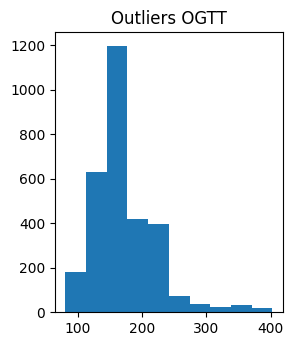

In [96]:
plt.figure(figsize=(10,8))
plt.subplot(3,1,1)
plt.hist(df["BMI"])
plt.title("Outliers Of BMI")
plt.show()

plt.figure(figsize=(10,8))
plt.subplot(3,1,2)
plt.hist(df["HDL"])
plt.title("Outliers Of HDL")
plt.show()

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.hist(df["Sys"])
plt.title("Outliers Of Sys BP")
plt.show()

plt.figure(figsize=(10,8))
plt.subplot(2,2,2)
plt.hist(df["dia"])
plt.title("Outliers Of Dia BP")
plt.show()

plt.figure(figsize=(10,8))
plt.subplot(2,3,1)
plt.hist(df["Hemoglobin"])
plt.title("Outliers Of Hemoglobin")
plt.show()

plt.figure(figsize=(10,8))
plt.subplot(2,3,2)
plt.hist(df["OGTT"])
plt.title("Outliers OGTT")



In [97]:
df["dia"].value_counts()

dia
80     327
81     274
82     272
83     269
75     121
      ... 
122      3
117      3
124      2
120      2
123      2
Name: count, Length: 65, dtype: int64

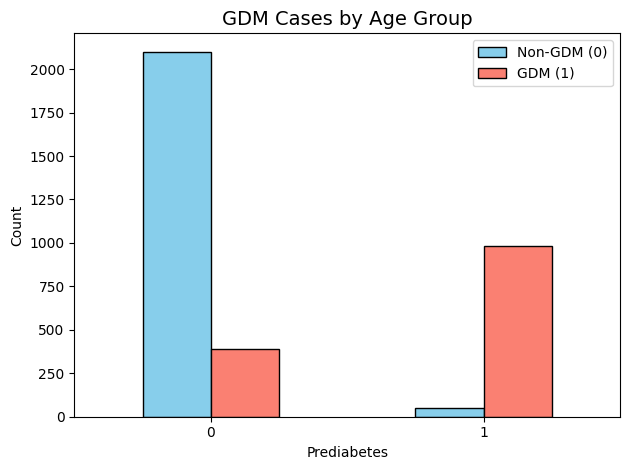

In [98]:
com = df.groupby(["Prediabetes", "GDM"]).size().unstack(fill_value=0)

com.plot(kind="bar", color=["skyblue", "salmon"], edgecolor="black")

plt.title("GDM Cases by Age Group", fontsize=14)
plt.xlabel("Prediabetes")
plt.ylabel("Count")
plt.legend(["Non-GDM (0)", "GDM (1)"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


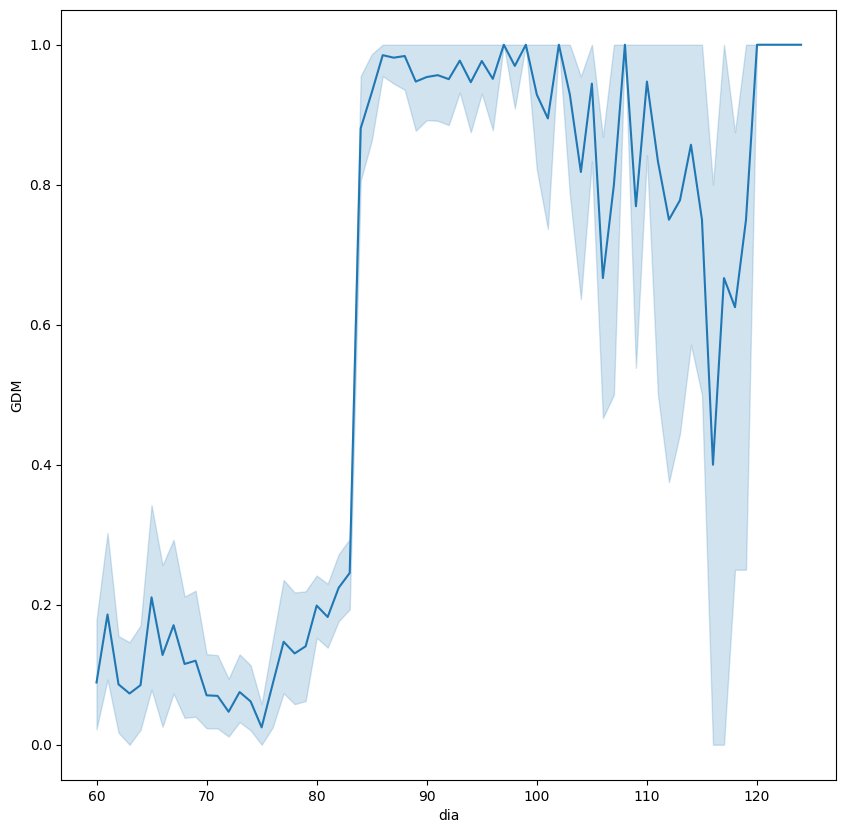

In [99]:
plt.figure(figsize = (10,10))
sns.lineplot(x="dia",y="GDM",data=df)
plt.show()

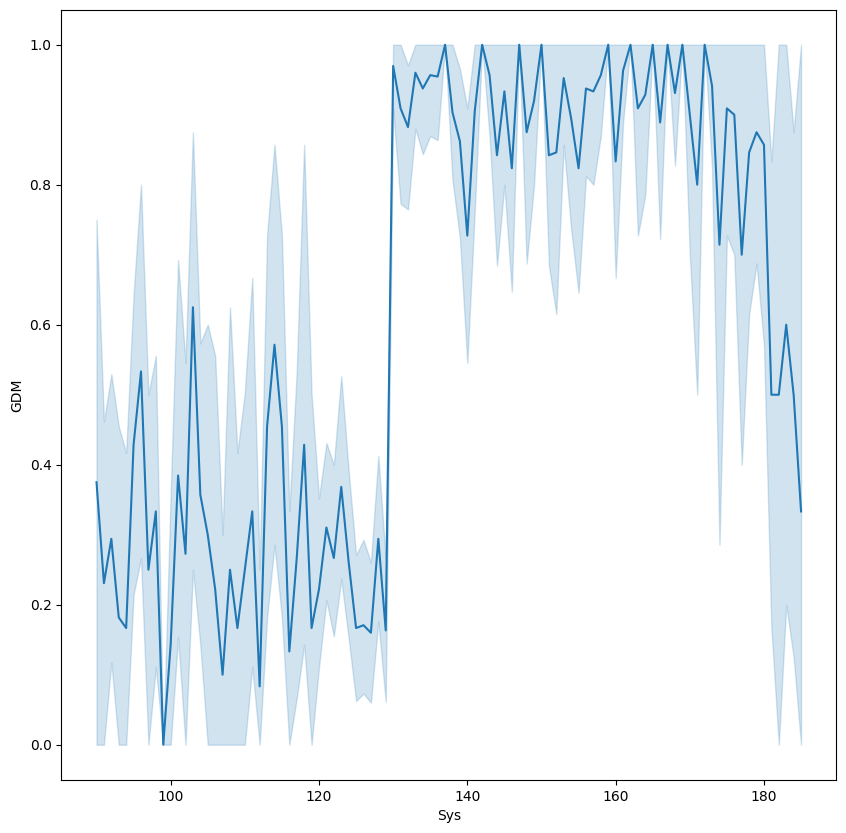

In [100]:
plt.figure(figsize = (10,10))
sns.lineplot(x="Sys",y="GDM",data=df)
plt.show()

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3525 entries, 0 to 3524
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Case Number                      3525 non-null   int64  
 1   Age                              3525 non-null   int64  
 2   No_of_Pregnancy                  3525 non-null   int64  
 3   Gestation_in_previous_Pregnancy  3525 non-null   int64  
 4   BMI                              2444 non-null   float64
 5   HDL                              2524 non-null   float64
 6   Family_History                   3525 non-null   int64  
 7   unexplained_prenetal_loss        3525 non-null   int64  
 8   Large_Child_or_Birth_Default     3525 non-null   int64  
 9   PCOS                             3525 non-null   int64  
 10  Sys                              1820 non-null   float64
 11  dia                              3525 non-null   int64  
 12  OGTT                

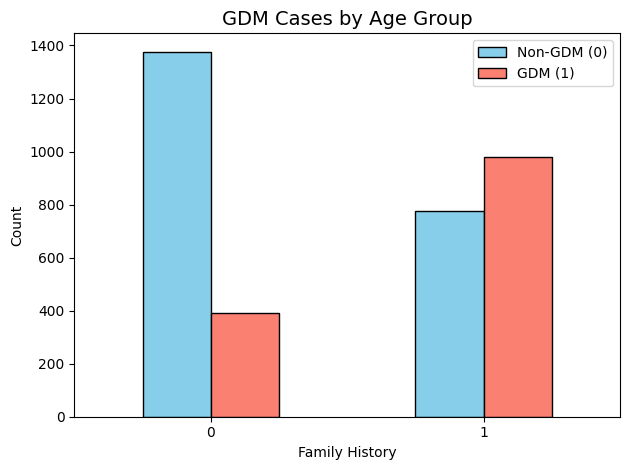

In [102]:
com = df.groupby(["Family_History", "GDM"]).size().unstack(fill_value=0)

com.plot(kind="bar", color=["skyblue", "salmon"], edgecolor="black")

plt.title("GDM Cases by Age Group", fontsize=14)
plt.xlabel("Family History")
plt.ylabel("Count")
plt.legend(["Non-GDM (0)", "GDM (1)"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


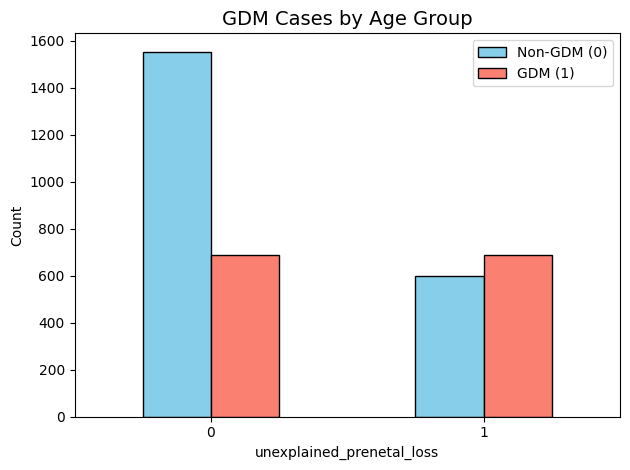

In [103]:
com = df.groupby(["unexplained_prenetal_loss", "GDM"]).size().unstack(fill_value=0)

com.plot(kind="bar", color=["skyblue", "salmon"], edgecolor="black")

plt.title("GDM Cases by Age Group", fontsize=14)
plt.xlabel("unexplained_prenetal_loss")
plt.ylabel("Count")
plt.legend(["Non-GDM (0)", "GDM (1)"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


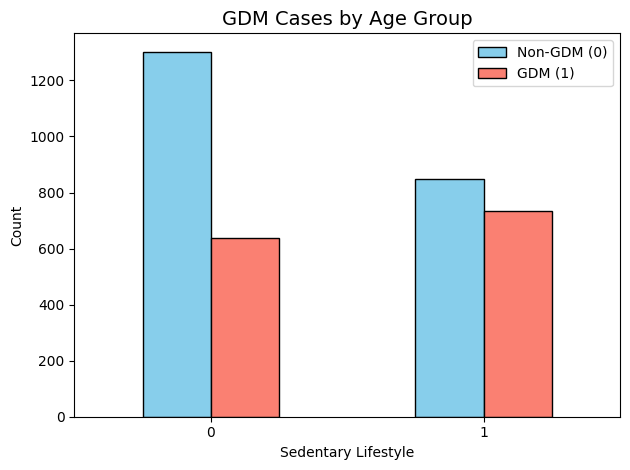

In [104]:
com = df.groupby(["Sedentary_Lifestyle", "GDM"]).size().unstack(fill_value=0)

com.plot(kind="bar", color=["skyblue", "salmon"], edgecolor="black")

plt.title("GDM Cases by Age Group", fontsize=14)
plt.xlabel("Sedentary Lifestyle")
plt.ylabel("Count")
plt.legend(["Non-GDM (0)", "GDM (1)"])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


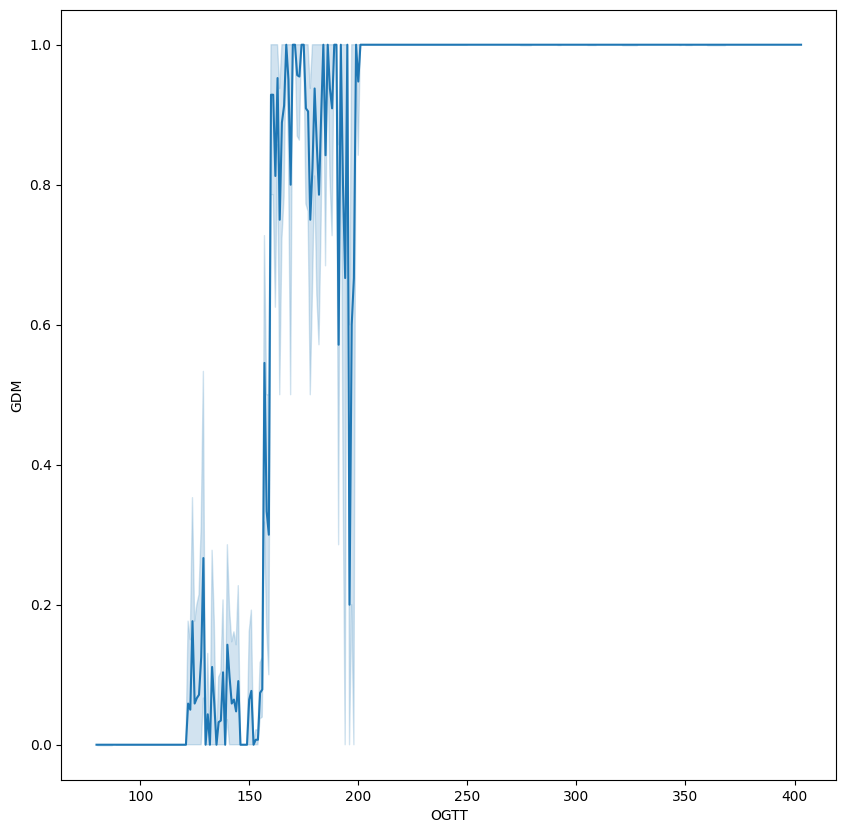

In [105]:
plt.figure(figsize = (10,10))
sns.lineplot(x="OGTT",y="GDM",data=df)
plt.show()

<Axes: xlabel='dia', ylabel='Sys'>

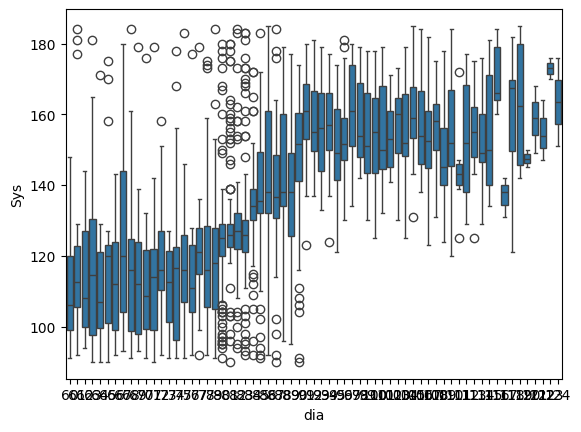

In [106]:

sns.boxplot(x='dia',y='Sys',data = df)

<Axes: xlabel='HDL', ylabel='BMI'>

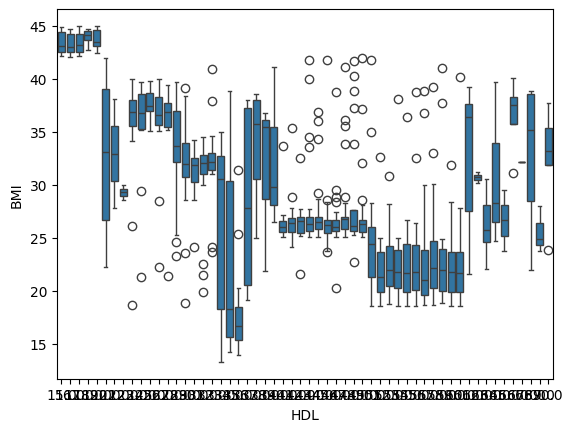

In [107]:
sns.boxplot(x='HDL',y='BMI',data = df)

<Axes: xlabel='Sedentary_Lifestyle', ylabel='HDL'>

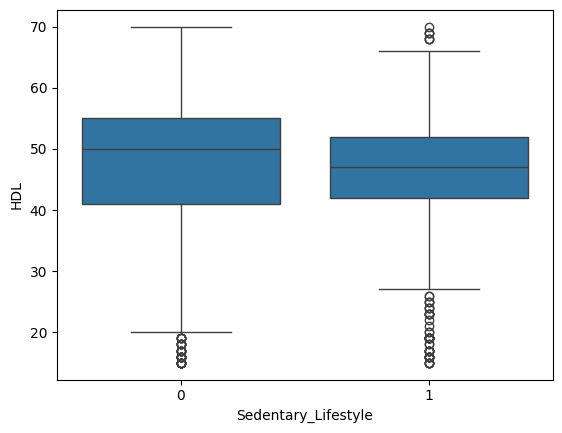

In [108]:
sns.boxplot(x='Sedentary_Lifestyle',y='HDL',data = df)

<Axes: xlabel='GDM', ylabel='HDL'>

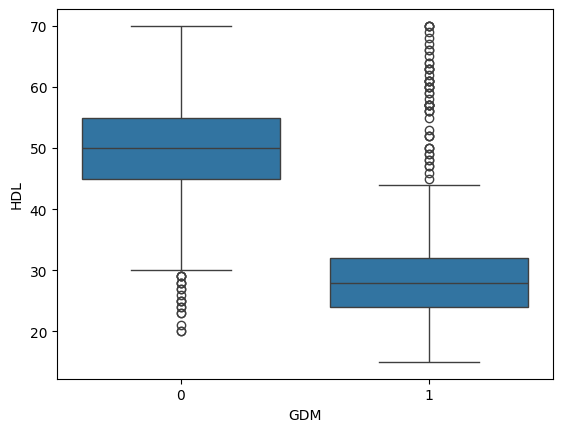

In [109]:
sns.boxplot(x='GDM',y='HDL',data = df)

<Axes: xlabel='HDL', ylabel='BMI'>

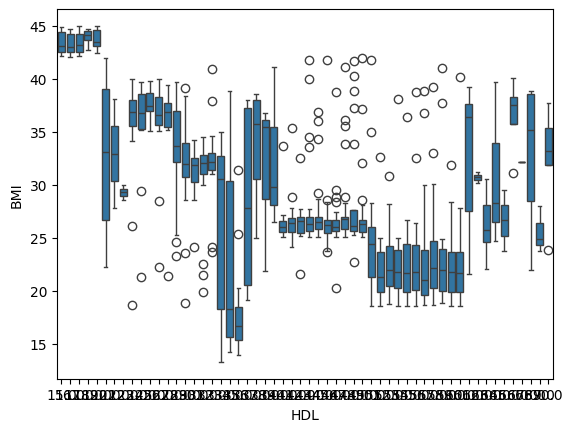

In [110]:
sns.boxplot(x='HDL',y='BMI',data = df)

<Axes: xlabel='HDL', ylabel='Age'>

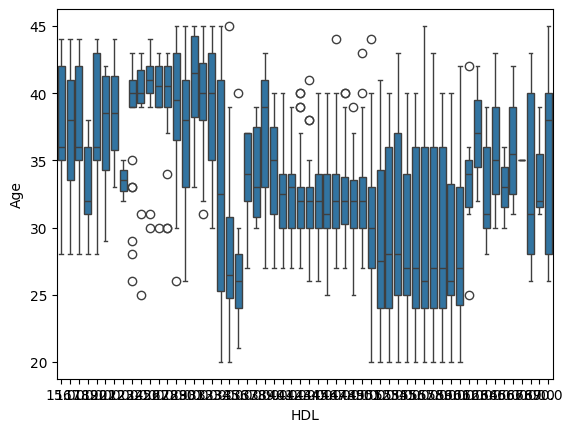

In [111]:
sns.boxplot(x='HDL',y='Age',data = df)

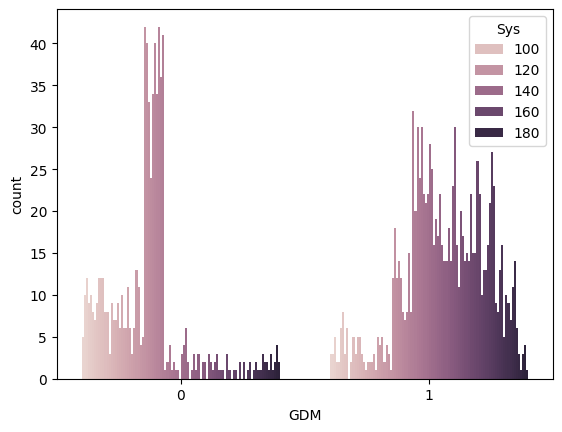

In [112]:
sns.countplot(x='GDM',hue='Sys',data = df)
plt.show()

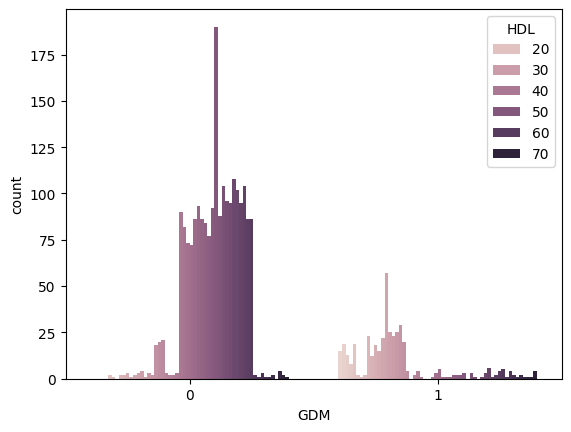

In [113]:
sns.countplot(x='GDM',hue='HDL',data = df)
plt.show()


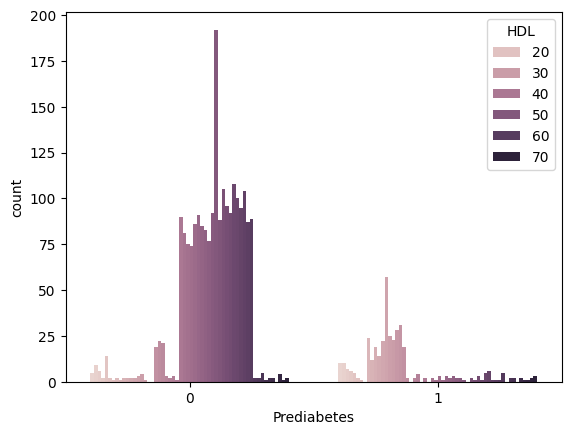

In [114]:
sns.countplot(x='Prediabetes',hue='HDL',data = df)
plt.show()

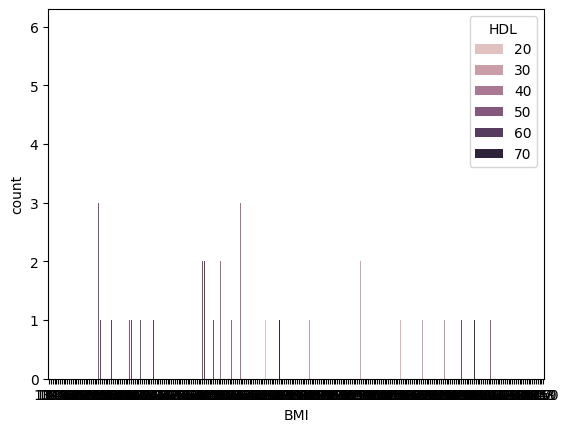

In [115]:

sns.countplot(x='BMI',hue='HDL',data = df)
plt.show()

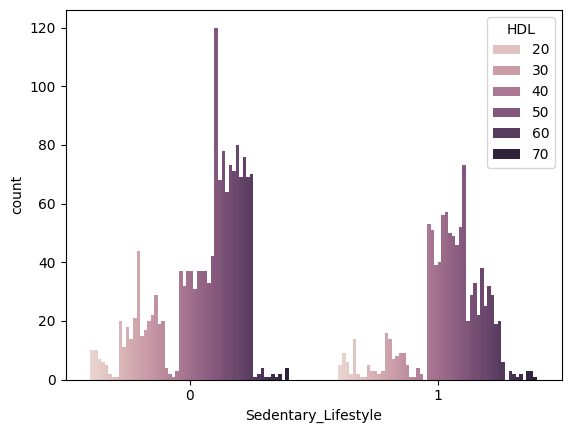

In [116]:
sns.countplot(x='Sedentary_Lifestyle',hue='HDL',data = df)
plt.show()

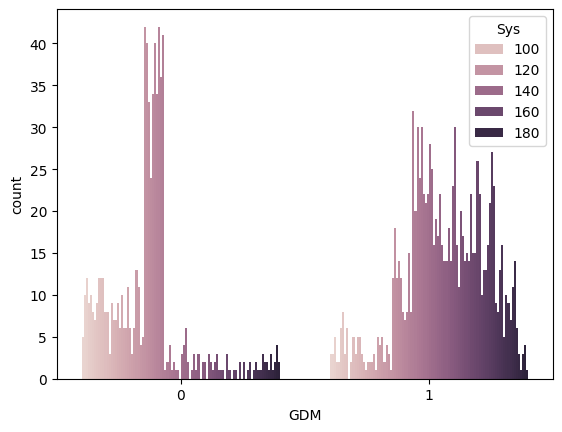

In [117]:
sns.countplot(x='GDM',hue='Sys',data = df)
plt.show()

<Axes: xlabel='OGTT', ylabel='BMI'>

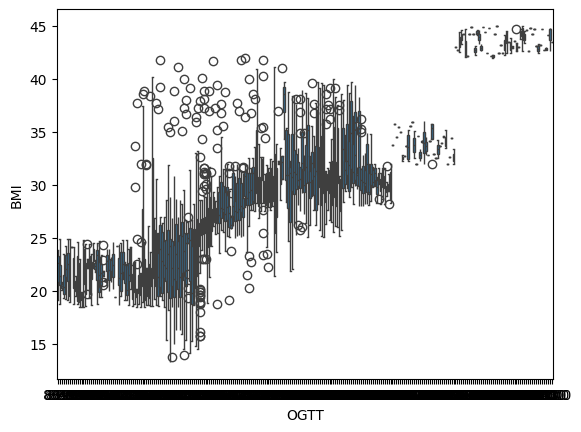

In [118]:
sns.boxplot(x='OGTT',y='BMI',data = df)

## Preprocessing


In [119]:
#1- feature selection
#2- Null Values
#3- outliers 
#4- Splitting

### 1- feature selection

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3525 entries, 0 to 3524
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Case Number                      3525 non-null   int64  
 1   Age                              3525 non-null   int64  
 2   No_of_Pregnancy                  3525 non-null   int64  
 3   Gestation_in_previous_Pregnancy  3525 non-null   int64  
 4   BMI                              2444 non-null   float64
 5   HDL                              2524 non-null   float64
 6   Family_History                   3525 non-null   int64  
 7   unexplained_prenetal_loss        3525 non-null   int64  
 8   Large_Child_or_Birth_Default     3525 non-null   int64  
 9   PCOS                             3525 non-null   int64  
 10  Sys                              1820 non-null   float64
 11  dia                              3525 non-null   int64  
 12  OGTT                

In [121]:
df.drop(columns = ['Case Number'],inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3525 entries, 0 to 3524
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              3525 non-null   int64  
 1   No_of_Pregnancy                  3525 non-null   int64  
 2   Gestation_in_previous_Pregnancy  3525 non-null   int64  
 3   BMI                              2444 non-null   float64
 4   HDL                              2524 non-null   float64
 5   Family_History                   3525 non-null   int64  
 6   unexplained_prenetal_loss        3525 non-null   int64  
 7   Large_Child_or_Birth_Default     3525 non-null   int64  
 8   PCOS                             3525 non-null   int64  
 9   Sys                              1820 non-null   float64
 10  dia                              3525 non-null   int64  
 11  OGTT                             3012 non-null   float64
 12  Hemoglobin          

In [122]:
df.head()

,Age,No_of_Pregnancy,Gestation_in_previous_Pregnancy,BMI,HDL,Family_History,unexplained_prenetal_loss,Large_Child_or_Birth_Default,PCOS,Sys,dia,OGTT,Hemoglobin,Sedentary_Lifestyle,Prediabetes,GDM
0,22,2,1,NaN,55.0,0,0,0,0,102.0,69,NaN,12.0,0,0,0
1,26,2,1,NaN,53.0,0,0,0,0,101.0,63,NaN,12.4,0,0,0
2,29,1,0,NaN,50.0,0,0,0,0,118.0,79,NaN,14.3,0,0,0
3,28,2,1,NaN,51.0,0,0,0,0,99.0,70,NaN,15.0,0,0,0
4,21,2,1,NaN,52.0,0,0,0,0,116.0,65,NaN,15.0,0,0,0


### 2-Handle Null Values

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3525 entries, 0 to 3524
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              3525 non-null   int64  
 1   No_of_Pregnancy                  3525 non-null   int64  
 2   Gestation_in_previous_Pregnancy  3525 non-null   int64  
 3   BMI                              2444 non-null   float64
 4   HDL                              2524 non-null   float64
 5   Family_History                   3525 non-null   int64  
 6   unexplained_prenetal_loss        3525 non-null   int64  
 7   Large_Child_or_Birth_Default     3525 non-null   int64  
 8   PCOS                             3525 non-null   int64  
 9   Sys                              1820 non-null   float64
 10  dia                              3525 non-null   int64  
 11  OGTT                             3012 non-null   float64
 12  Hemoglobin          

<Axes: xlabel='Prediabetes', ylabel='BMI'>

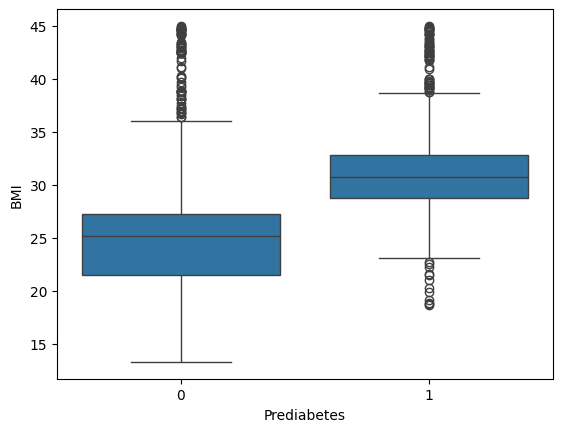

In [124]:
sns.boxplot(x='Prediabetes',y='BMI',data = df)

In [125]:
# if Prediabetes=0 BMI between 23 - 27  else  BMI between 29 - 33
rng = np.random.default_rng(42)
def imput_nulls_BMI(cols):
    BMI=cols[0]
    target=cols[1]
    if pd.isnull(BMI):
        if target == 0:
            return float(rng.uniform(23, 27))
        else :
            return float(rng.uniform(29, 33))
    else:
        return BMI
df['BMI']=df[['BMI','Prediabetes']].apply(imput_nulls_BMI,axis=1)
df.isna().sum()

Age                                   0
No_of_Pregnancy                       0
Gestation_in_previous_Pregnancy       0
BMI                                   0
HDL                                1001
Family_History                        0
unexplained_prenetal_loss             0
Large_Child_or_Birth_Default          0
PCOS                                  0
Sys                                1705
dia                                   0
OGTT                                513
Hemoglobin                            0
Sedentary_Lifestyle                   0
Prediabetes                           0
GDM                                   0
dtype: int64

<Axes: xlabel='Prediabetes', ylabel='HDL'>

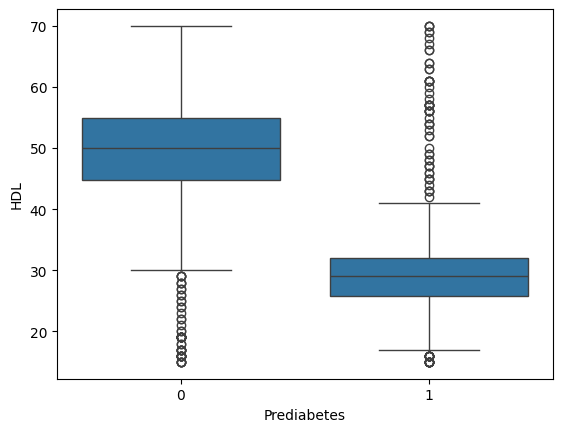

In [126]:
sns.boxplot(x='Prediabetes',y='HDL',data = df)

In [127]:
# if Prediabetes=0 HDL between 46 - 55  else  HDL between 27 - 32
rng = np.random.default_rng(42)
def imput_nulls_HDL(cols):
    HDL=cols[0]
    target=cols[1]
    if pd.isnull(HDL):
        if target == 0:
            return float(rng.uniform(46, 55))
        else :
            return float(rng.uniform(27, 32))
    else:
        return HDL
df['HDL']=df[['HDL','Prediabetes']].apply(imput_nulls_BMI,axis=1)
df.isna().sum()

Age                                   0
No_of_Pregnancy                       0
Gestation_in_previous_Pregnancy       0
BMI                                   0
HDL                                   0
Family_History                        0
unexplained_prenetal_loss             0
Large_Child_or_Birth_Default          0
PCOS                                  0
Sys                                1705
dia                                   0
OGTT                                513
Hemoglobin                            0
Sedentary_Lifestyle                   0
Prediabetes                           0
GDM                                   0
dtype: int64

<Axes: xlabel='Prediabetes', ylabel='Sys'>

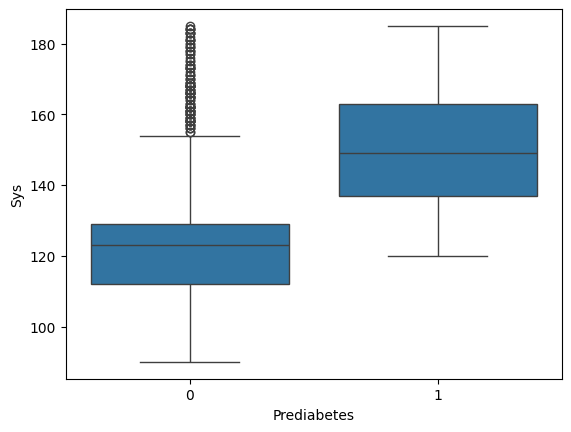

In [128]:
sns.boxplot(x='Prediabetes',y='Sys',data = df)

In [129]:
# if Prediabetes=0 Sys between 113 - 127  else  Sys between 139 - 162
rng = np.random.default_rng(42)
def imput_nulls_Sys(cols):
    Sys=cols[0]
    target=cols[1]
    if pd.isnull(Sys):
        if target == 0:
            return float(rng.uniform(113, 127))
        else :
            return float(rng.uniform(139, 162))
    else:
        return Sys
df['Sys']=df[['Sys','Prediabetes']].apply(imput_nulls_Sys,axis=1)
df.isna().sum()

Age                                  0
No_of_Pregnancy                      0
Gestation_in_previous_Pregnancy      0
BMI                                  0
HDL                                  0
Family_History                       0
unexplained_prenetal_loss            0
Large_Child_or_Birth_Default         0
PCOS                                 0
Sys                                  0
dia                                  0
OGTT                               513
Hemoglobin                           0
Sedentary_Lifestyle                  0
Prediabetes                          0
GDM                                  0
dtype: int64

<Axes: xlabel='Prediabetes', ylabel='OGTT'>

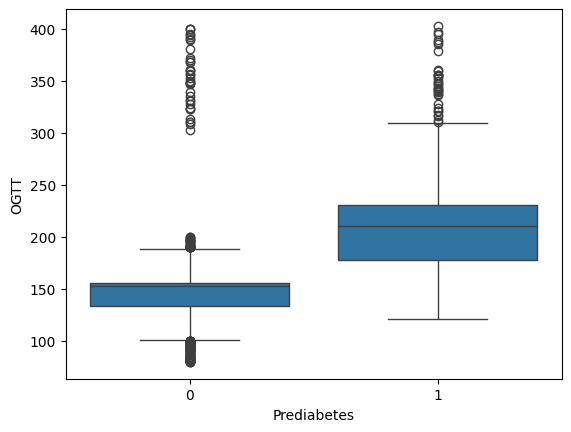

In [130]:
sns.boxplot(x='Prediabetes',y='OGTT',data = df)

In [131]:
# if Prediabetes=0 OGTT between 137 - 157  else  OGTT between 180 - 230
rng = np.random.default_rng(42)
def imput_nulls_OGTT(cols):
    OGTT=cols[0]
    target=cols[1]
    if pd.isnull(OGTT):
        if target == 0:
            return float(rng.uniform(137, 157))
        else :
            return float(rng.uniform(180, 230))
    else:
        return OGTT
df['OGTT']=df[['OGTT','Sedentary_Lifestyle']].apply(imput_nulls_OGTT,axis=1)
df.isna().sum()

Age                                0
No_of_Pregnancy                    0
Gestation_in_previous_Pregnancy    0
BMI                                0
HDL                                0
Family_History                     0
unexplained_prenetal_loss          0
Large_Child_or_Birth_Default       0
PCOS                               0
Sys                                0
dia                                0
OGTT                               0
Hemoglobin                         0
Sedentary_Lifestyle                0
Prediabetes                        0
GDM                                0
dtype: int64

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3525 entries, 0 to 3524
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              3525 non-null   int64  
 1   No_of_Pregnancy                  3525 non-null   int64  
 2   Gestation_in_previous_Pregnancy  3525 non-null   int64  
 3   BMI                              3525 non-null   float64
 4   HDL                              3525 non-null   float64
 5   Family_History                   3525 non-null   int64  
 6   unexplained_prenetal_loss        3525 non-null   int64  
 7   Large_Child_or_Birth_Default     3525 non-null   int64  
 8   PCOS                             3525 non-null   int64  
 9   Sys                              3525 non-null   float64
 10  dia                              3525 non-null   int64  
 11  OGTT                             3525 non-null   float64
 12  Hemoglobin          

### 3- Outliers

In [133]:
df.describe()

,Age,No_of_Pregnancy,Gestation_in_previous_Pregnancy,BMI,HDL,Family_History,unexplained_prenetal_loss,Large_Child_or_Birth_Default,PCOS,Sys,dia,OGTT,Hemoglobin,Sedentary_Lifestyle,Prediabetes,GDM
count,3525.000000,3525.000000,3525.000000,3525.000000,3525.000000,3525.000000,3525.000000,3525.00000,3525.000000,3525.000000,3525.000000,3525.000000,3525.000000,3525.000000,3525.000000,3525.000000
mean,32.581277,2.076312,0.960851,26.977000,41.475450,0.498156,0.364823,0.35773,0.264681,130.349305,81.538156,167.467456,13.959801,0.449645,0.293050,0.389220
std,6.169107,0.838637,0.722313,4.979129,12.215308,0.500068,0.481449,0.47940,0.441226,19.144122,11.379758,45.410295,1.863969,0.497529,0.455226,0.487643
min,20.000000,1.000000,0.000000,13.300000,15.000000,0.000000,0.000000,0.00000,0.000000,90.000000,60.000000,80.000000,8.800000,0.000000,0.000000,0.000000
25%,28.000000,1.000000,0.000000,24.112453,30.456768,0.000000,0.000000,0.00000,0.000000,118.280026,74.000000,142.000000,12.700000,0.000000,0.000000,0.000000
50%,32.000000,2.000000,1.000000,26.109373,43.000000,0.000000,0.000000,0.00000,0.000000,124.497231,81.000000,155.000000,14.000000,0.000000,0.000000,0.000000
75%,37.000000,3.000000,1.000000,29.600000,52.000000,1.000000,1.000000,1.00000,1.000000,143.000000,86.000000,184.000000,15.000000,1.000000,1.000000,1.000000
max,45.000000,4.000000,2.000000,45.000000,70.000000,1.000000,1.000000,1.00000,1.000000,185.000000,124.000000,403.000000,18.000000,1.000000,1.000000,1.000000


<Axes: xlabel='OGTT'>

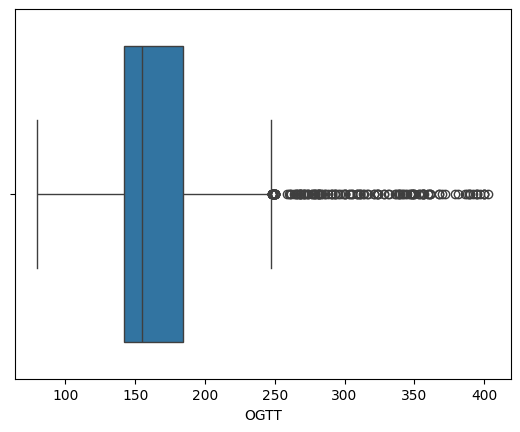

In [134]:
sns.boxplot(x= 'OGTT',data = df)

<Axes: xlabel='dia'>

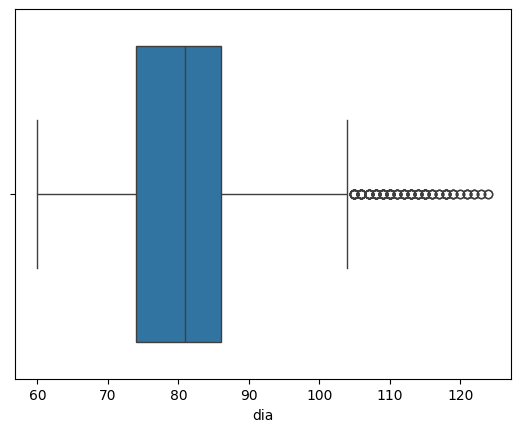

In [135]:
sns.boxplot(x= 'dia',data = df)

<Axes: xlabel='Sys'>

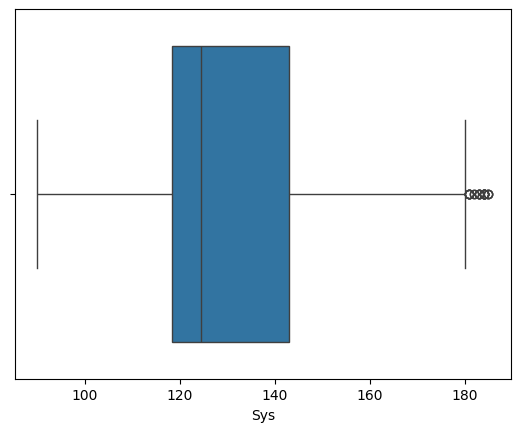

In [136]:
sns.boxplot(x= 'Sys',data = df)

<Axes: xlabel='HDL'>

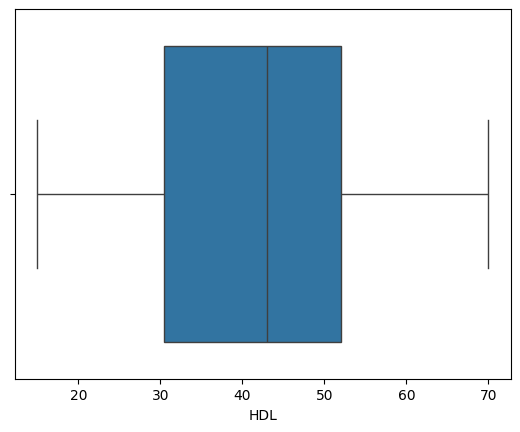

In [137]:
sns.boxplot(x= 'HDL',data = df)

<Axes: xlabel='BMI'>

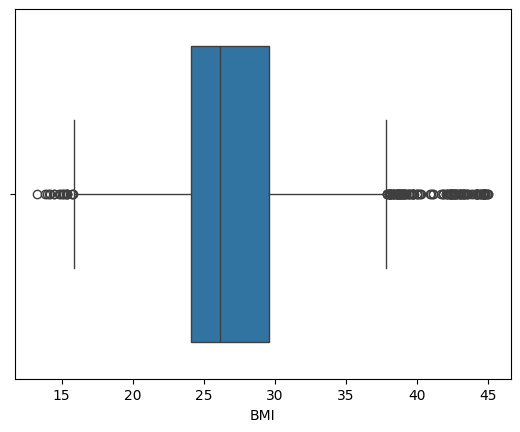

In [138]:
sns.boxplot(x= 'BMI',data = df)

In [139]:
X = df.drop(columns=['GDM'])
y = df['GDM']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)
#from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler()
#x_train.loc[:, scale_cols] = scaler.fit_transform(x_train[scale_cols]) 
#x_test.loc[:,  scale_cols] = scaler.transform(x_test[scale_cols])      
x_train.head()


,Age,No_of_Pregnancy,Gestation_in_previous_Pregnancy,BMI,HDL,Family_History,unexplained_prenetal_loss,Large_Child_or_Birth_Default,PCOS,Sys,dia,OGTT,Hemoglobin,Sedentary_Lifestyle,Prediabetes
3244,31,2,2,35.700000,28.000000,1,0,1,1,153.000000,81,260.0,13.3,1,1
2492,25,3,2,30.500000,32.149729,1,1,1,1,165.000000,86,232.0,15.7,1,1
1967,32,3,1,20.700000,53.000000,0,0,0,0,117.817975,75,98.0,12.3,0,0
1040,30,3,1,23.366895,47.000000,1,0,1,0,123.284695,82,156.0,13.0,1,0
1201,24,1,0,19.600000,59.000000,0,0,0,0,123.089743,75,121.0,16.0,0,0


In [140]:
cols = ['Sys','dia','HDL','BMI','OGTT']
q1 = x_train[cols].quantile(0.25)
q3 = x_train[cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr
mask_train = ((x_train[cols] >= lower) & (x_train[cols] <= upper)).all(axis=1)
x_train = x_train[mask_train]
y_train = y_train[mask_train]

### Splitting

In [141]:
print('x_train shape: ',x_train.shape)
print('y_train shape: ',y_train.shape)
print('--'*20)
print('x_test shape: ',x_test.shape)

print('y_test shape: ',y_test.shape)

x_train shape:  (2516, 15)
y_train shape:  (2516,)
----------------------------------------
x_test shape:  (705, 15)
y_test shape:  (705,)


## Classification -- LogisticRegression

In [142]:
best_model, final_scaler, best_params, best_score = tune_logistic_full_recall_no_pipeline(
    x_train, y_train, x_test, y_test
)
best_threshold, threshold_results = find_best_threshold_from_cv(
    x_train, y_train, best_params
)
print("Best Threshold from CV:", best_threshold)


Best Params: {'C': 0.003, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Recall: 0.9905743125652627

Confusion Matrix:
 [[404  27]
 [  1 273]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.94      0.97       431
           1       0.91      1.00      0.95       274

    accuracy                           0.96       705
   macro avg       0.95      0.97      0.96       705
weighted avg       0.96      0.96      0.96       705

Test ROC-AUC: 0.9876539028231748
    threshold   TP    TN    FP   FN    recall  precision
0        0.10  848   487  1181    0  1.000000   0.417940
1        0.25  845  1305   363    3  0.996462   0.699503
2        0.20  845  1050   618    3  0.996462   0.577580
3        0.15  845   759   909    3  0.996462   0.481756
4        0.30  843  1501   167    5  0.994104   0.834653
5        0.40  842  1622    46    6  0.992925   0.948198
6        0.35  842  1580    88    6  0.99292

In [143]:
chosen_threshold = 0.40

x_test_scaled = final_scaler.transform(x_test)
y_prob_test = best_model.predict_proba(x_test_scaled)[:, 1]
y_pred_LR = (y_prob_test >= chosen_threshold).astype(int)


model_evaluation(y_test, y_pred_LR)

Accuracy: 0.9517730496453901

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       431
           1       0.89      1.00      0.94       274

    accuracy                           0.95       705
   macro avg       0.94      0.96      0.95       705
weighted avg       0.96      0.95      0.95       705


Confusion Matrix:
[[398  33]
 [  1 273]]
Recall: 0.9598921198367403
F1 : 0.9502077274615703


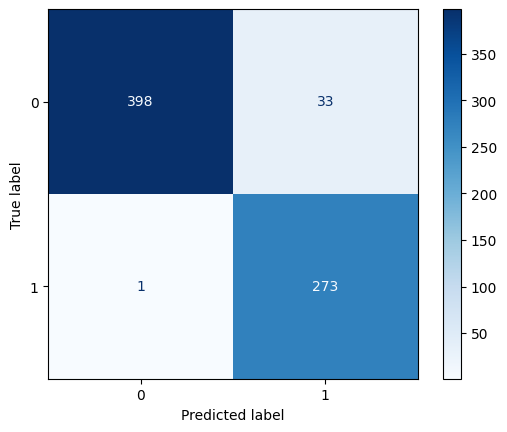

In [144]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_LR))
disp.plot(cmap="Blues")

In [145]:
chosen_threshold = 0.45

x_test_scaled = final_scaler.transform(x_test)
y_prob_test = best_model.predict_proba(x_test_scaled)[:, 1]
y_pred_LR = (y_prob_test >= chosen_threshold).astype(int)


model_evaluation(y_test, y_pred_LR)

Accuracy: 0.9602836879432625

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       431
           1       0.91      1.00      0.95       274

    accuracy                           0.96       705
   macro avg       0.95      0.97      0.96       705
weighted avg       0.96      0.96      0.96       705


Confusion Matrix:
[[404  27]
 [  1 273]]
Recall: 0.9668526766812877
F1 : 0.9588633446143073


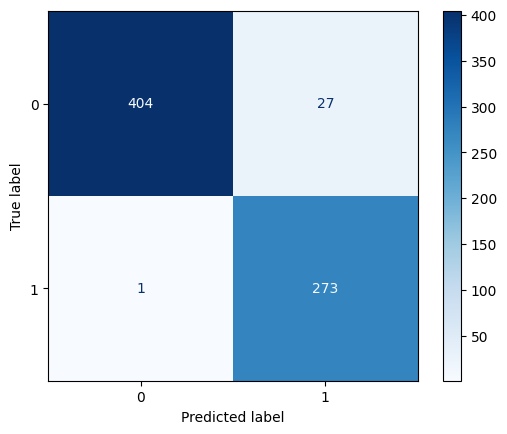

In [146]:
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_LR))
disp.plot(cmap="Blues")

In [147]:
x_train.columns

Index(['Age', 'No_of_Pregnancy', 'Gestation_in_previous_Pregnancy', 'BMI',
       'HDL', 'Family_History', 'unexplained_prenetal_loss',
       'Large_Child_or_Birth_Default', 'PCOS', 'Sys', 'dia', 'OGTT',
       'Hemoglobin', 'Sedentary_Lifestyle', 'Prediabetes'],
      dtype='object')

In [148]:
import joblib

chosen_threshold = 0.45

final_artifact = {
    "model": best_model,
    "scaler": final_scaler,
    "threshold": float(chosen_threshold),
    "feature_order": list(X.columns)
}

joblib.dump(final_artifact, "gdm_artifact.pkl")
print("artifact saved")

artifact saved


In [149]:
import requests

url = "http://127.0.0.1:8000/predict"

data = {
    "Age": 30,
    "No_of_Pregnancy": 2,
    "Gestation_in_previous_Pregnancy": 1,
    "BMI": 27.5,
    "HDL": 45,
    "Family_History": 1,
    "unexplained_prenetal_loss": 0,
    "Large_Child_or_Birth_Default": 0,
    "PCOS": 1,
    "Sys": 120,
    "dia": 80,
    "OGTT": 140,
    "Hemoglobin": 11.8,
    "Sedentary_Lifestyle": 1,
    "Prediabetes": 0
}

response = requests.post(url, json=data)

print(response.status_code)
print(response.json())

200
{'label': 'GDM Negative', 'probability': 0.3632}


In [ ]:

import joblib
final_artifact = {
    "model": best_model,
    "threshold": 0.45
}

joblib.dump(final_artifact, "Last_logistic_model.pkl")

['Last_logistic_model.pkl']

In [ ]:
loaded_model = joblib.load("Last_logistic_model.pkl")["model"]
x_test_scaled = final_scaler.transform(x_test)

y_prob = loaded_model.predict_proba(x_test_scaled)[:, 1]
y_pred_LR = (y_prob >= 0.45).astype(int)

cm = confusion_matrix(y_test, y_pred_LR)
print(cm)

[[404  27]
 [  1 273]]


## Classification -- SVM

#### Linear 

In [102]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score as acc
svm_c=SVC(kernel = 'linear',C=3.8699999999999615)
svm_c.fit(x_train,y_train)
svm_pred=svm_c.predict(x_test)
svm_pred_train=svm_c.predict(x_train)
print('training accuracy  : ',(acc(y_train,svm_pred_train))*100)
print('testing accuracy : ',(acc(y_test,svm_pred))*100)
model_evaluation(y_test, svm_pred)

training accuracy  :  99.00635930047694
testing accuracy :  96.31205673758865
Accuracy: 0.9631205673758865

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       431
           1       0.93      0.98      0.95       274

    accuracy                           0.96       705
   macro avg       0.96      0.97      0.96       705
weighted avg       0.96      0.96      0.96       705


Confusion Matrix:
[[411  20]
 [  6 268]]
F1 : 0.96153813872289


#### Poly

In [103]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score as acc
svm_deg=SVC(kernel = 'poly',degree = 12)
svm_deg.fit(x_train,y_train)
svm_pred=svm_deg.predict(x_test)
svm_pred_train=svm_deg.predict(x_train)
print('training accuracy  : ',(acc(y_train,svm_pred_train))*100)
print('testing accuracy : ',(acc(y_test,svm_pred))*100)
model_evaluation(y_test, svm_pred)

training accuracy  :  99.24483306836248
testing accuracy :  97.16312056737588
Accuracy: 0.9716312056737588

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       431
           1       0.96      0.97      0.96       274

    accuracy                           0.97       705
   macro avg       0.97      0.97      0.97       705
weighted avg       0.97      0.97      0.97       705


Confusion Matrix:
[[420  11]
 [  9 265]]
F1 : 0.9701902748414376


#### RBF

In [104]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score as acc
svm_deg=SVC(kernel = 'rbf',gamma=0.003)
svm_deg.fit(x_train,y_train)
svm_pred=svm_deg.predict(x_test)
svm_pred_train=svm_deg.predict(x_train)
mx_train=acc(y_train,svm_pred_train)*100
mx_test=acc(y_test,svm_pred)*100
print('training accuracy  : ',mx_train)
print('testing accuracy : ',mx_test)
model_evaluation(y_test, svm_pred)

training accuracy  :  99.72178060413354
testing accuracy :  97.30496453900709
Accuracy: 0.9730496453900709

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       431
           1       0.95      0.98      0.97       274

    accuracy                           0.97       705
   macro avg       0.97      0.97      0.97       705
weighted avg       0.97      0.97      0.97       705


Confusion Matrix:
[[418  13]
 [  6 268]]
F1 : 0.9717717717717718
